<div style="display:flex; align-items:center; justify-content:space-between; gap:32px; background:linear-gradient(135deg, #033622 0%, #0D5C36 100%); color:#FF4B00; padding:24px 36px; border-radius:16px; box-shadow:0 8px 24px rgba(0,37,76,0.25); font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif; position:relative; overflow:hidden;">
  <div style="position:absolute; top:0; right:0; width:300px; height:100%; background:radial-gradient(circle at 100% 50%, rgba(255,255,255,0.05) 0%, transparent 70%); pointer-events:none;"></div>

  <div style="z-index:1;">
    <div style="line-height:1.3;">
      <h1 style="margin:0; font-size:36px; font-weight:700; letter-spacing:-0.5px; text-shadow:0 2px 4px rgba(0,0,0,0.25);">Expected Danger Model</h1>
      <h2 style="margin:4px 0 0 0; font-size:24px; font-weight:400; opacity:0.95; text-shadow:0 1px 2px rgba(0,0,0,0.2);">Project 2</h2>
      <h3 style="margin:4px 0 0 0; font-size:16px; font-weight:300; opacity:0.85; letter-spacing:0.5px; text-shadow:0 1px 2px rgba(0,0,0,0.2);">Soccermatics Pro | Tiago Monteiro</h3>
    </div>
  </div>

  <div style="display:flex; align-items:center; gap:24px; z-index:1;">
    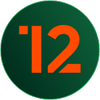
    
  </div>
</div>

<div style="
    font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
    color: #033622;
    border-bottom: 3px solid #FF4B00;
    padding-bottom: 8px;
    margin: 32px 0 16px 0;
    font-size: 28px;
    font-weight: 700;
    letter-spacing: -0.5px;
    display: flex;
    align-items: center;
    gap: 12px;
">
    Project Description
</div>

<div style="
    background-color: #f8f9fa; 
    border-left: 4px solid #FF4B00; 
    padding: 16px 24px; 
    border-radius: 0 4px 4px 0;
    font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
    color: #333;
">
    <p style="margin-top: 0; font-size: 16px;">
        In this exercise, we will create an <strong>"Expected Danger"</strong> model. Please complete the following steps:
    </p>
    <ol style="margin-bottom: 0; line-height: 1.6;">
        <li style="margin-bottom: 10px;">
            <strong>Data Filtering:</strong> Write code to identify all the passes made within <code>15 seconds</code> of a shot.
        </li>
        <li style="margin-bottom: 10px;">
            <strong>Shot Probability (Logistic Regression):</strong> Analyze how the start and end $(x,y)$ coordinates of these passes determine the probability that the pass will be followed by a shot within 15 seconds.
            <br>
            <em>Tip: Consider transforming the variables (e.g., distance to goal, angle) and using non-linear transformations when fitting the model.</em>
        </li>
        <li style="margin-bottom: 10px;">
            <strong>Goal Probability (Linear Regression):</strong> Analyze how the start and end $(x,y)$ coordinates of the pass determine the probability that the resulting shot is a goal.
        </li>
        <li style="margin-bottom: 10px;">
            <strong>Combined Expected Danger:</strong> Combine the models from steps 2 and 3 to calculate the total probability of a goal given the start and end coordinates of a pass.
        </li>
        <li>
            <strong>Player Ranking:</strong> Rank players (grouped by position) in terms of their <strong>"Expected Danger" per 90</strong>. Compare this ranking to the number of danger passes made per 90.
        </li>
    </ol>
</div>

<div style="
    font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
    color: #033622;
    border-bottom: 3px solid #FF4B00;
    padding-bottom: 8px;
    margin: 32px 0 16px 0;
    font-size: 28px;
    font-weight: 700;
    letter-spacing: -0.5px;
    display: flex;
    align-items: center;
    gap: 12px;
">
    Requirements
</div>

In [8]:
import json
import glob
import pandas as pd
import numpy as np
import os
import sys
from sklearn.linear_model import LogisticRegression, LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = 'data'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

## Model Evolution: V1 → V2

### Feature Engineering Improvements

**V1 Model** used **11 features**:
- Basic coordinates: `x_start`, `y_start`, `x_end`, `y_end`
- Distance to goal: `start_dist_goal`, `end_dist_goal`
- Angle to goal: `start_angle_goal`, `end_angle_goal`
- Squared distances: `start_dist_sq`, `end_dist_sq` (redundant)
- Distance delta: `distance_delta`

**V2 Model** expanded to **17 features** by:

**Removing redundant features:**
- ❌ `start_dist_sq`, `end_dist_sq` (perfectly correlated with distance features)

**Adding strategic features:**
- ✅ `pass_progression_x`, `pass_progression_y` - directional movement
- ✅ `pass_length` - pass difficulty metric
- ✅ `into_penalty_box`, `into_final_third` - danger zone indicators
- ✅ `vertical_progress_to_goal` - goal-oriented progress
- ✅ `angle_change` - change in shooting angle
- ✅ `match_phase` - temporal context (early/mid/late game)

### Performance Comparison

| Metric | V1 (11 features) | V2 (17 features) | Δ Change |
|--------|------------------|------------------|----------|
| **Model 1 AUC** (Shot Prediction) | 0.7626 | 0.7639 | +0.13% |
| **Model 2 R²** (Goal Prediction) | 0.0059 | 0.0093 | +0.33% |

#### Model Performance Comparison

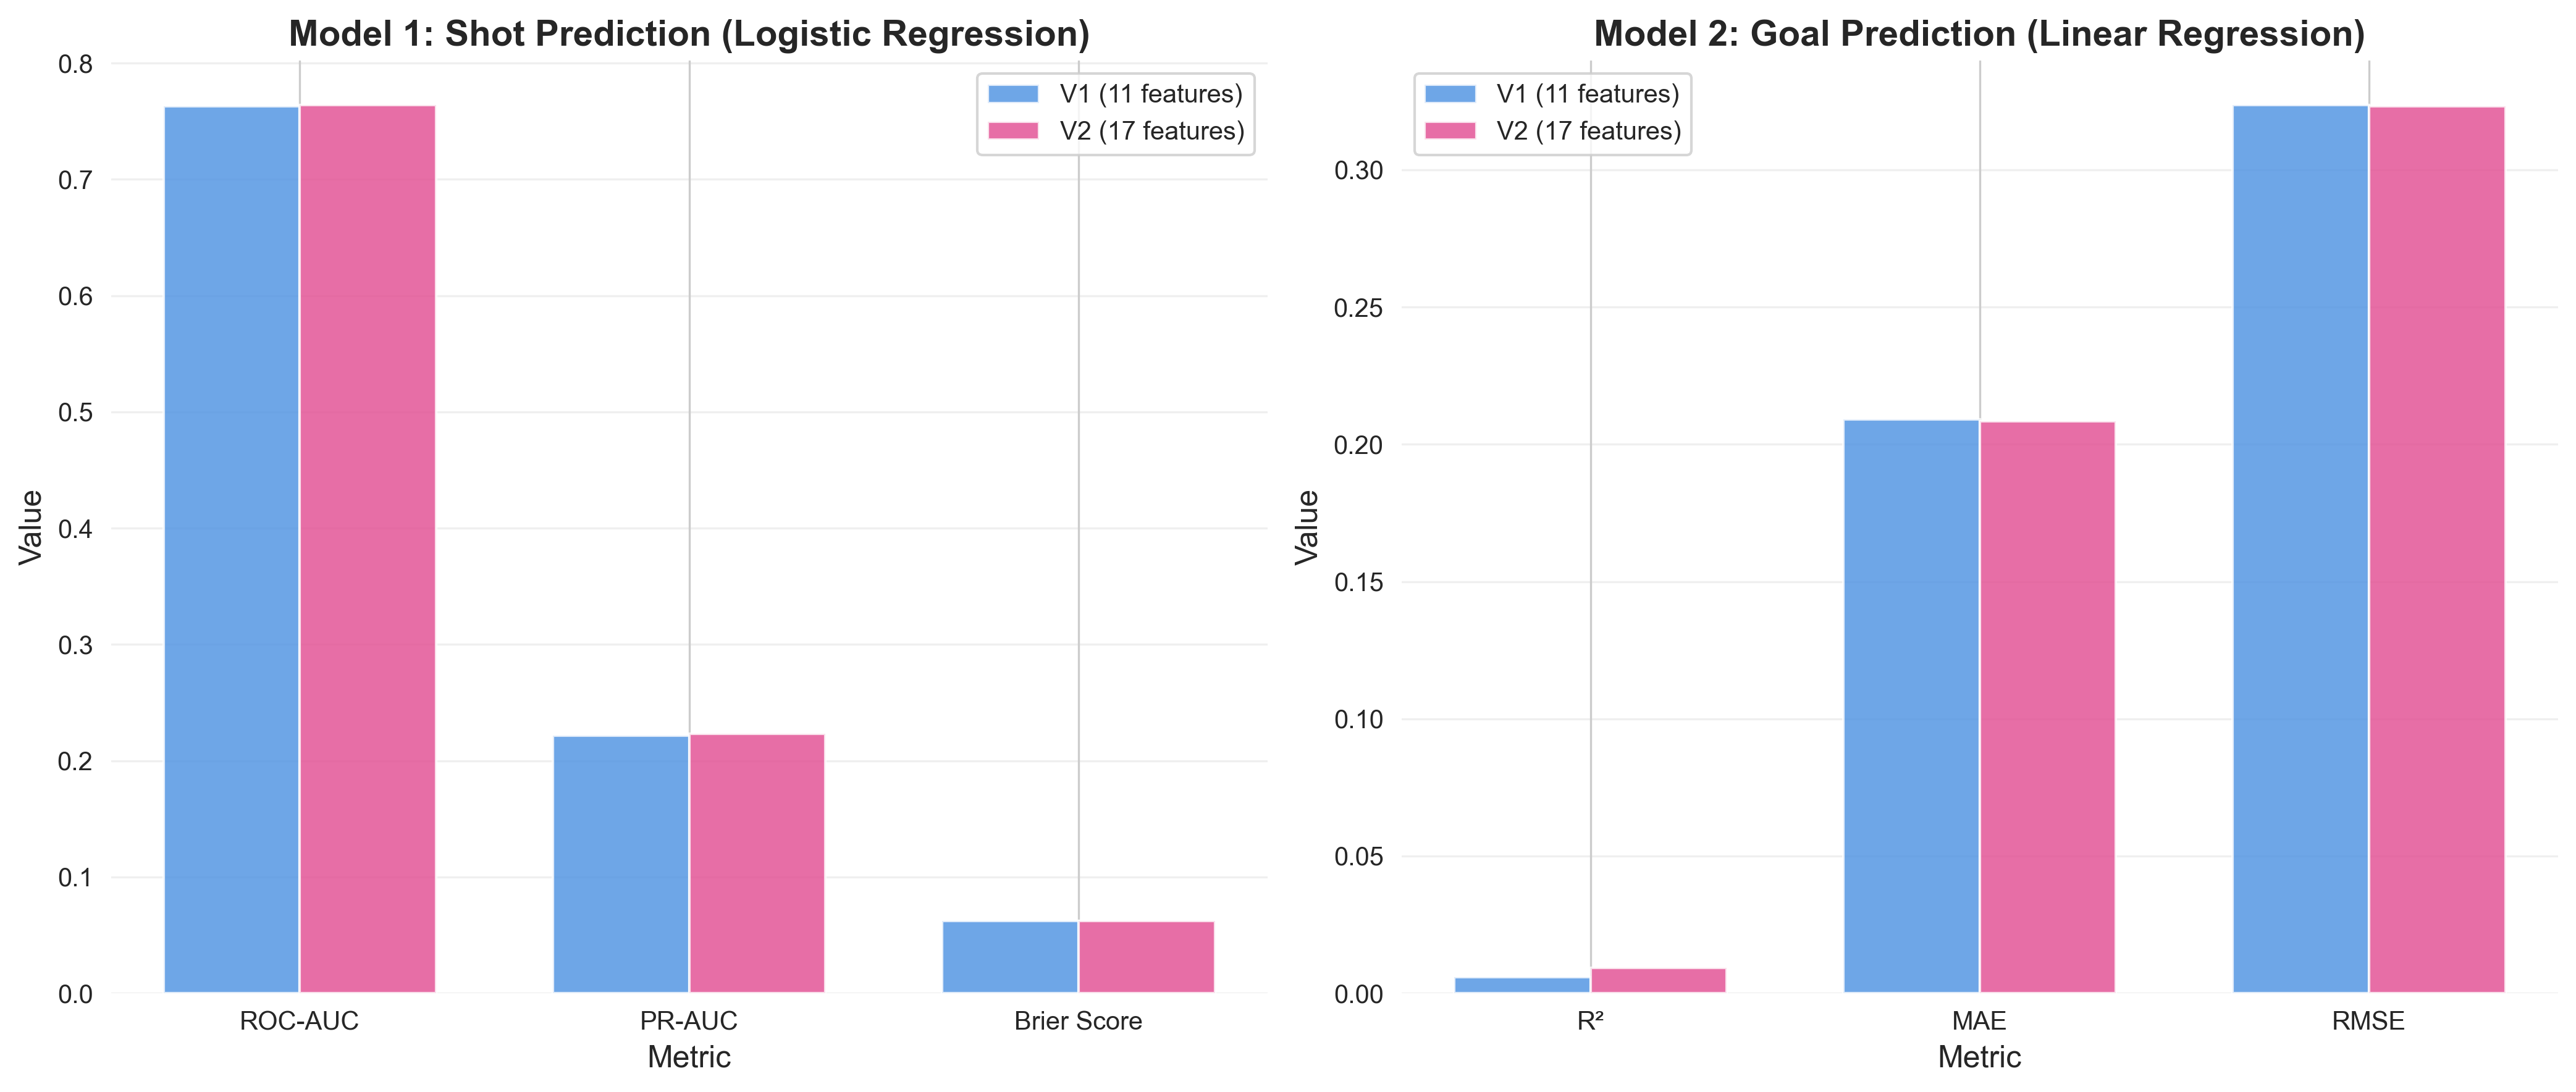

#### Feature Count Comparison

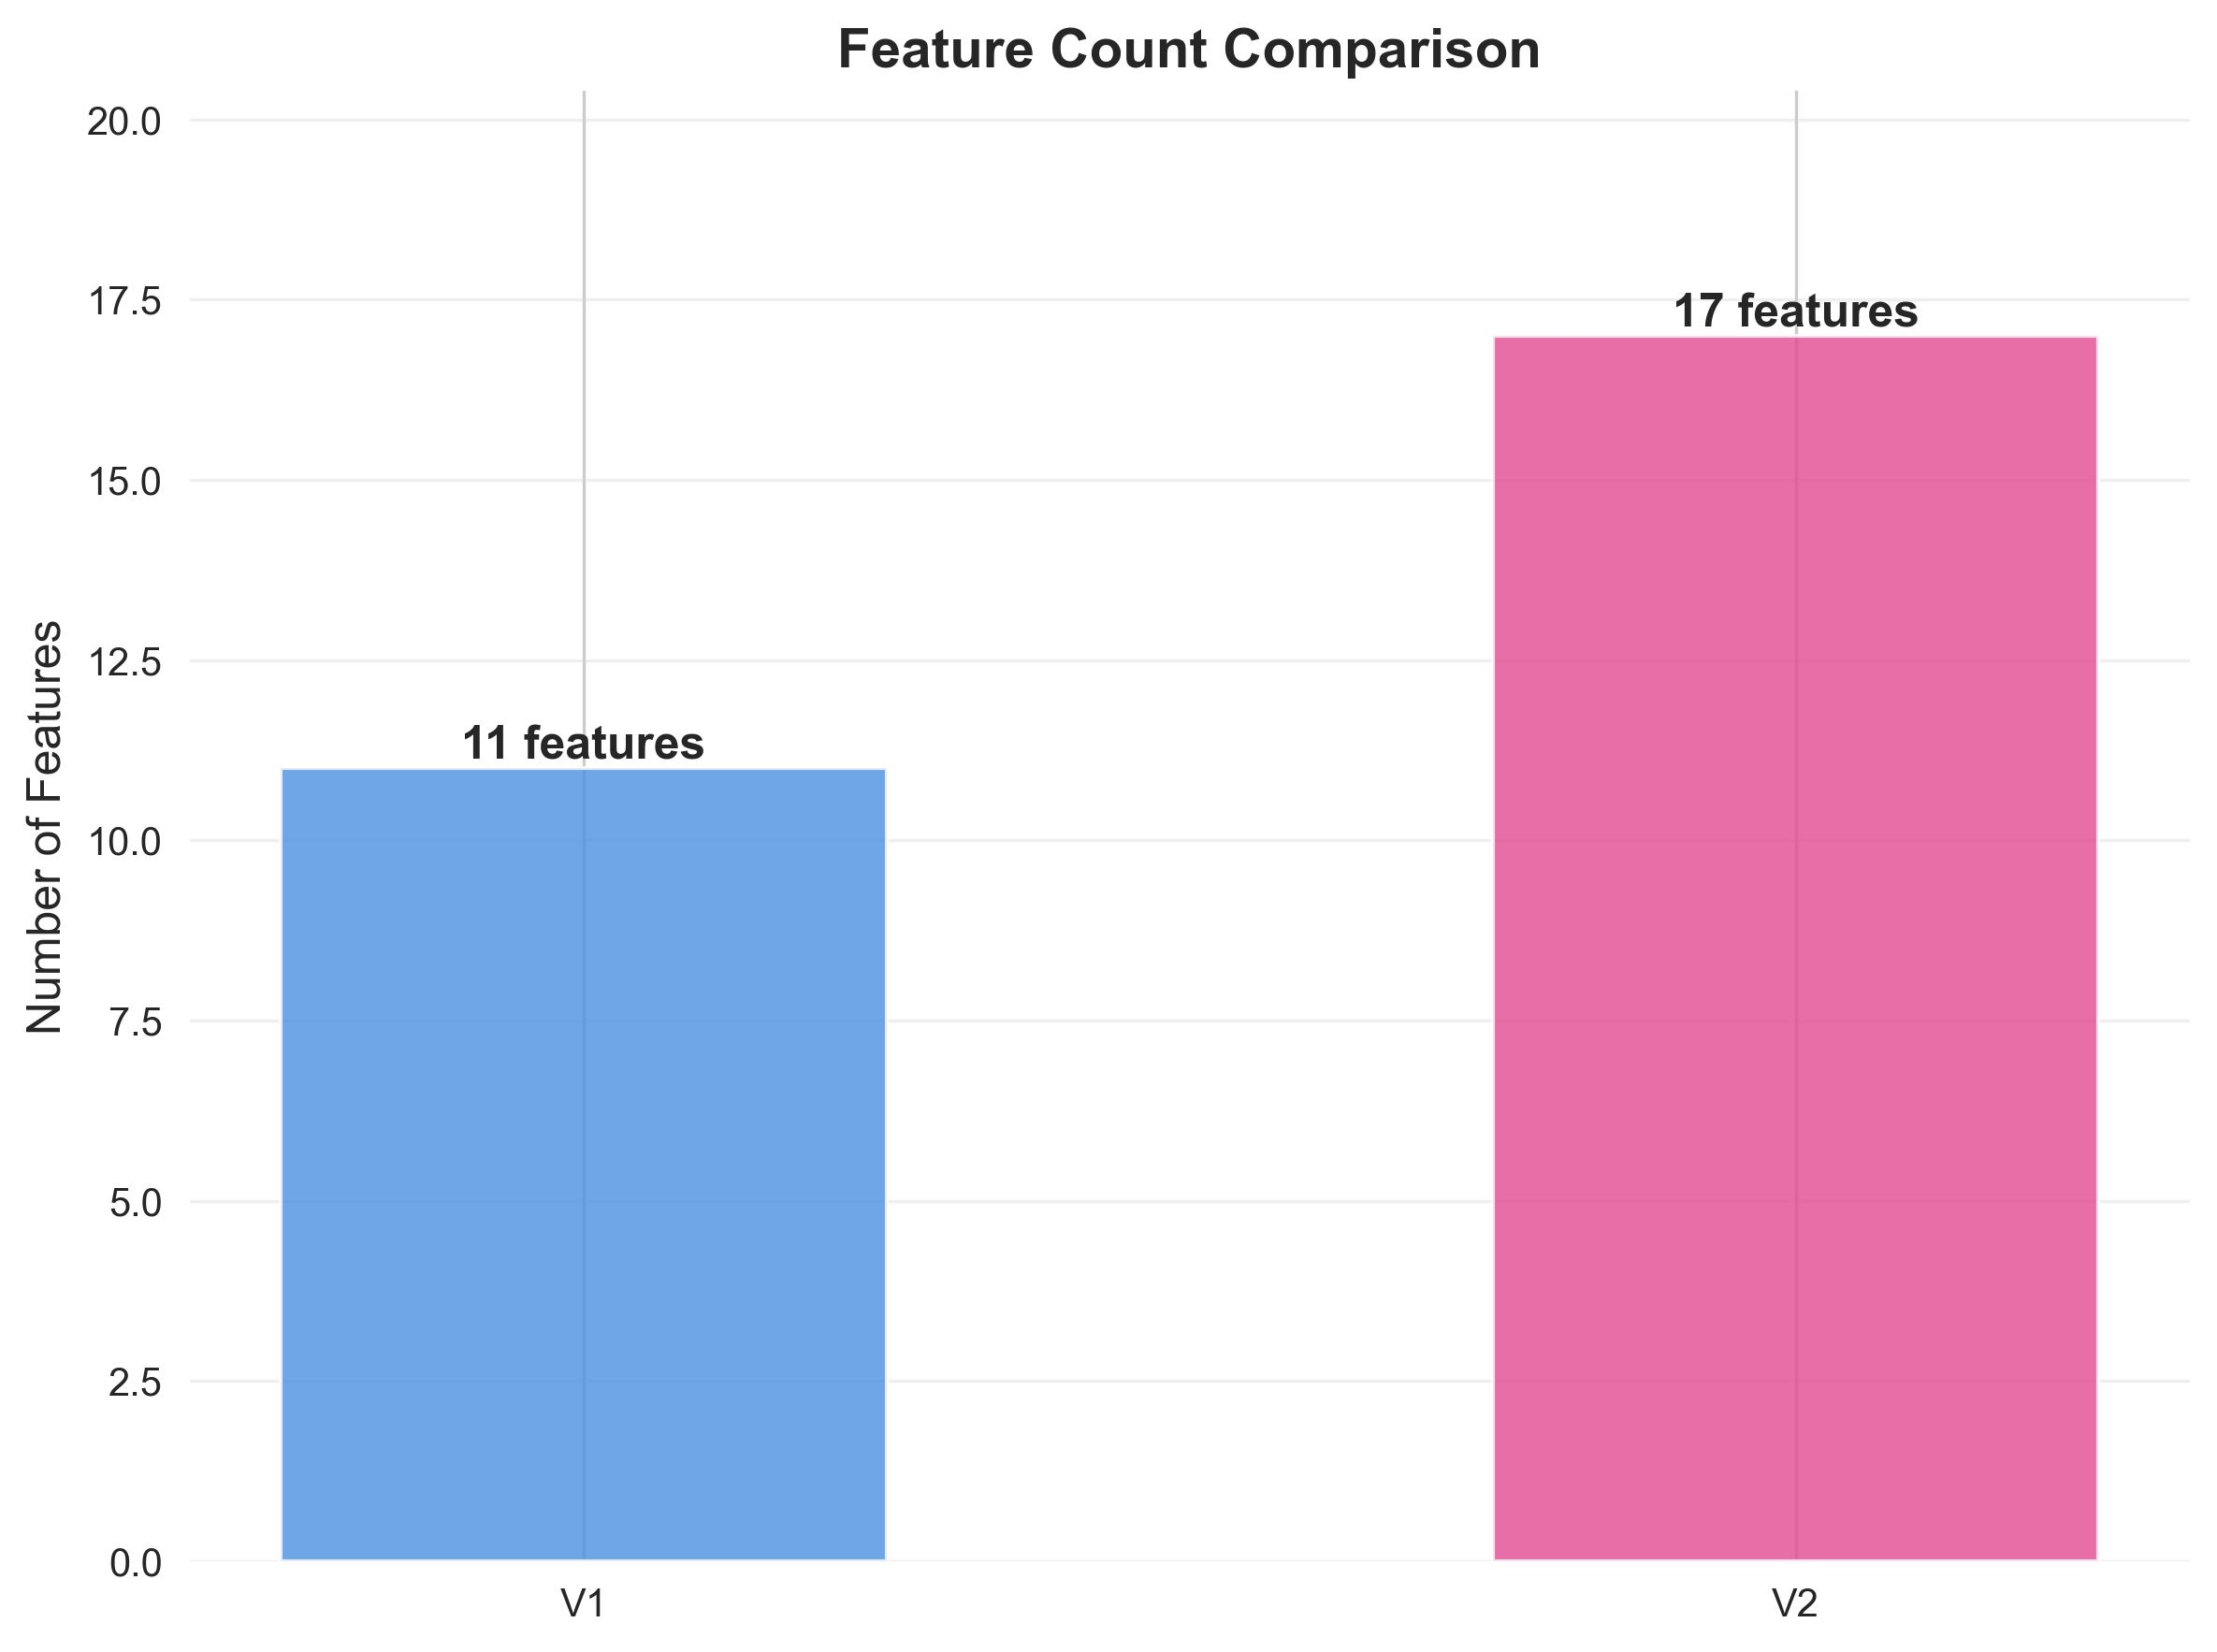



## Why Are the Results So Similar?

Despite adding 6 new features (and removing 2 redundant ones), the V2 model shows only **marginal improvements** over V1. Here's why:

### 1. Feature Correlation

The new features are **highly correlated** with existing ones:
- `into_final_third` is essentially `x_end >= 66.67`, which correlates strongly with `end_dist_goal`
- `into_penalty_box` correlates with very low `end_dist_goal` values
- `pass_progression_x` = `x_end - x_start`, already captured by coordinate features
- `vertical_progress_to_goal` = `distance_delta`, which already existed in V1

**Result:** New features provide little new information to the model.

### 2. Dominant Features Remain the Same

SHAP analysis reveals that **distance-based features still dominate** in both models:

**V1 Top Features:**
1. `end_dist_goal` - How close the pass ends to goal
2. `start_dist_goal` - Where the pass originates
3. `start_dist_sq` - Redundant squared term

**V2 Top Features:**
1. `end_dist_goal` - Still #1 most important
2. `start_dist_goal` - Still #2 most important
3. `into_final_third` - Binary version of distance information

The fundamental signal ("passes closer to goal are more dangerous") **dominates both models**.

### SHAP Feature Importance Comparison

**V1 Feature Importance (11 features):**

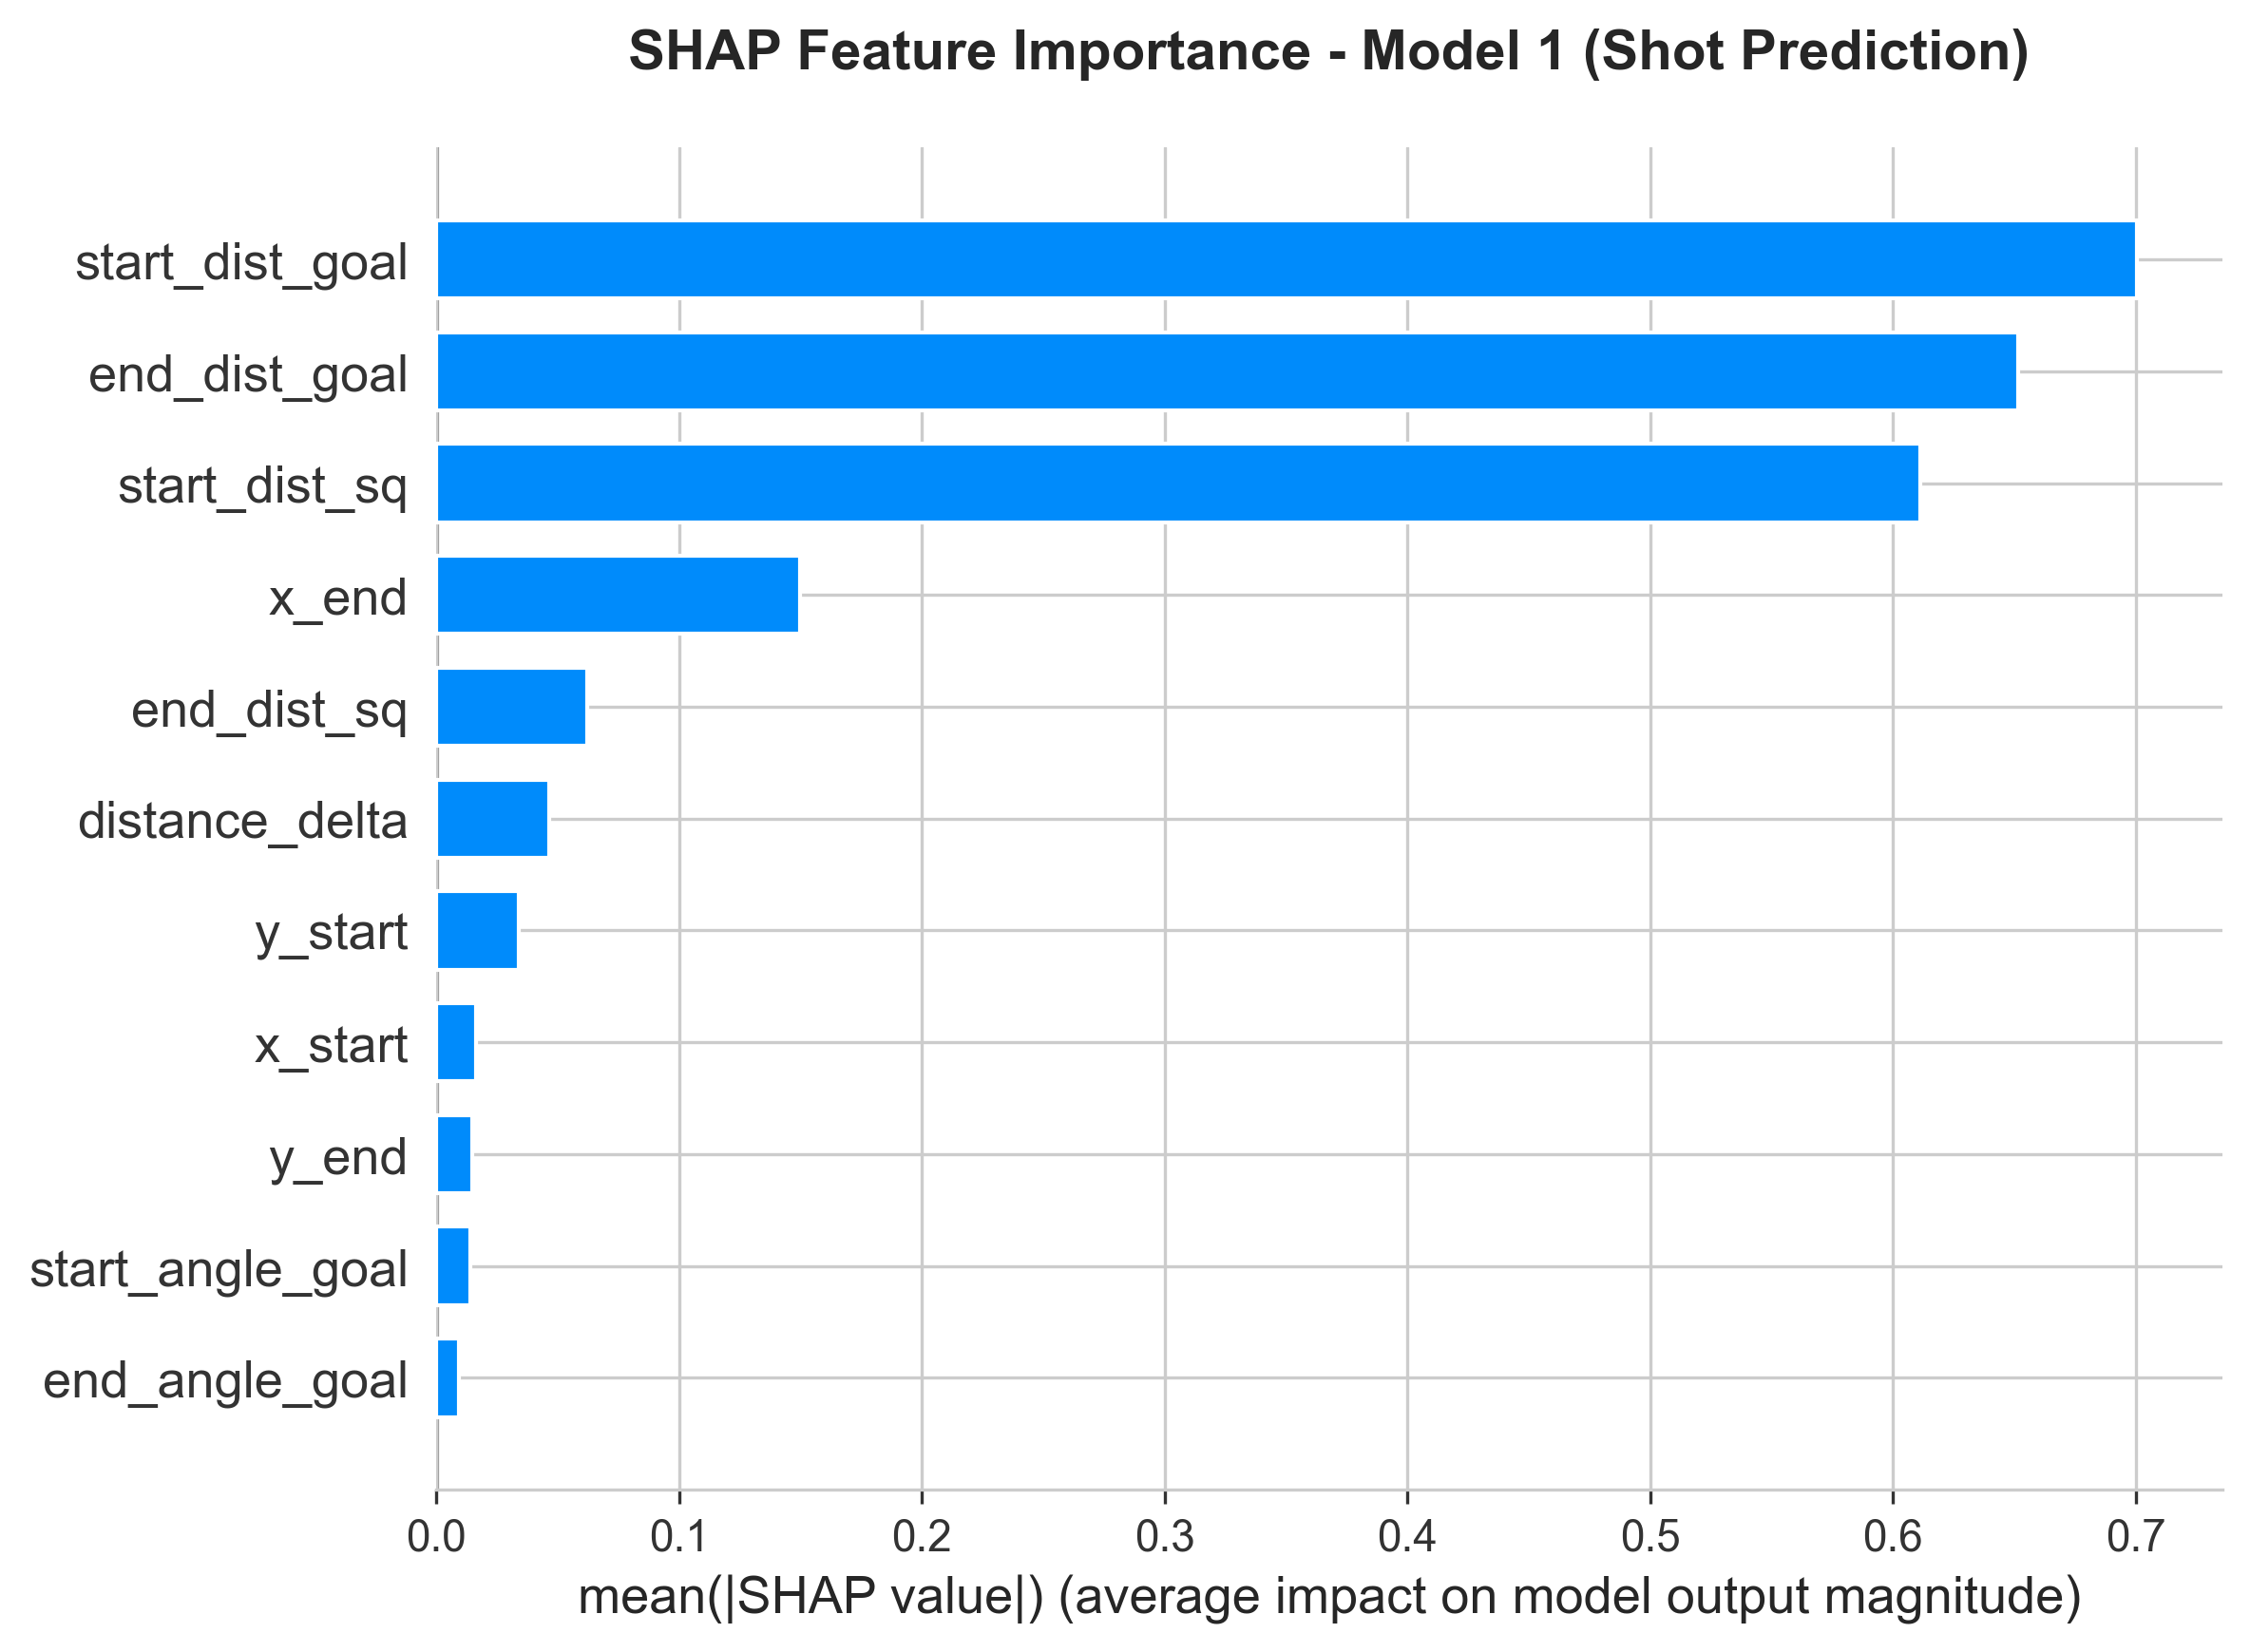

**V2 Feature Importance (17 features):**

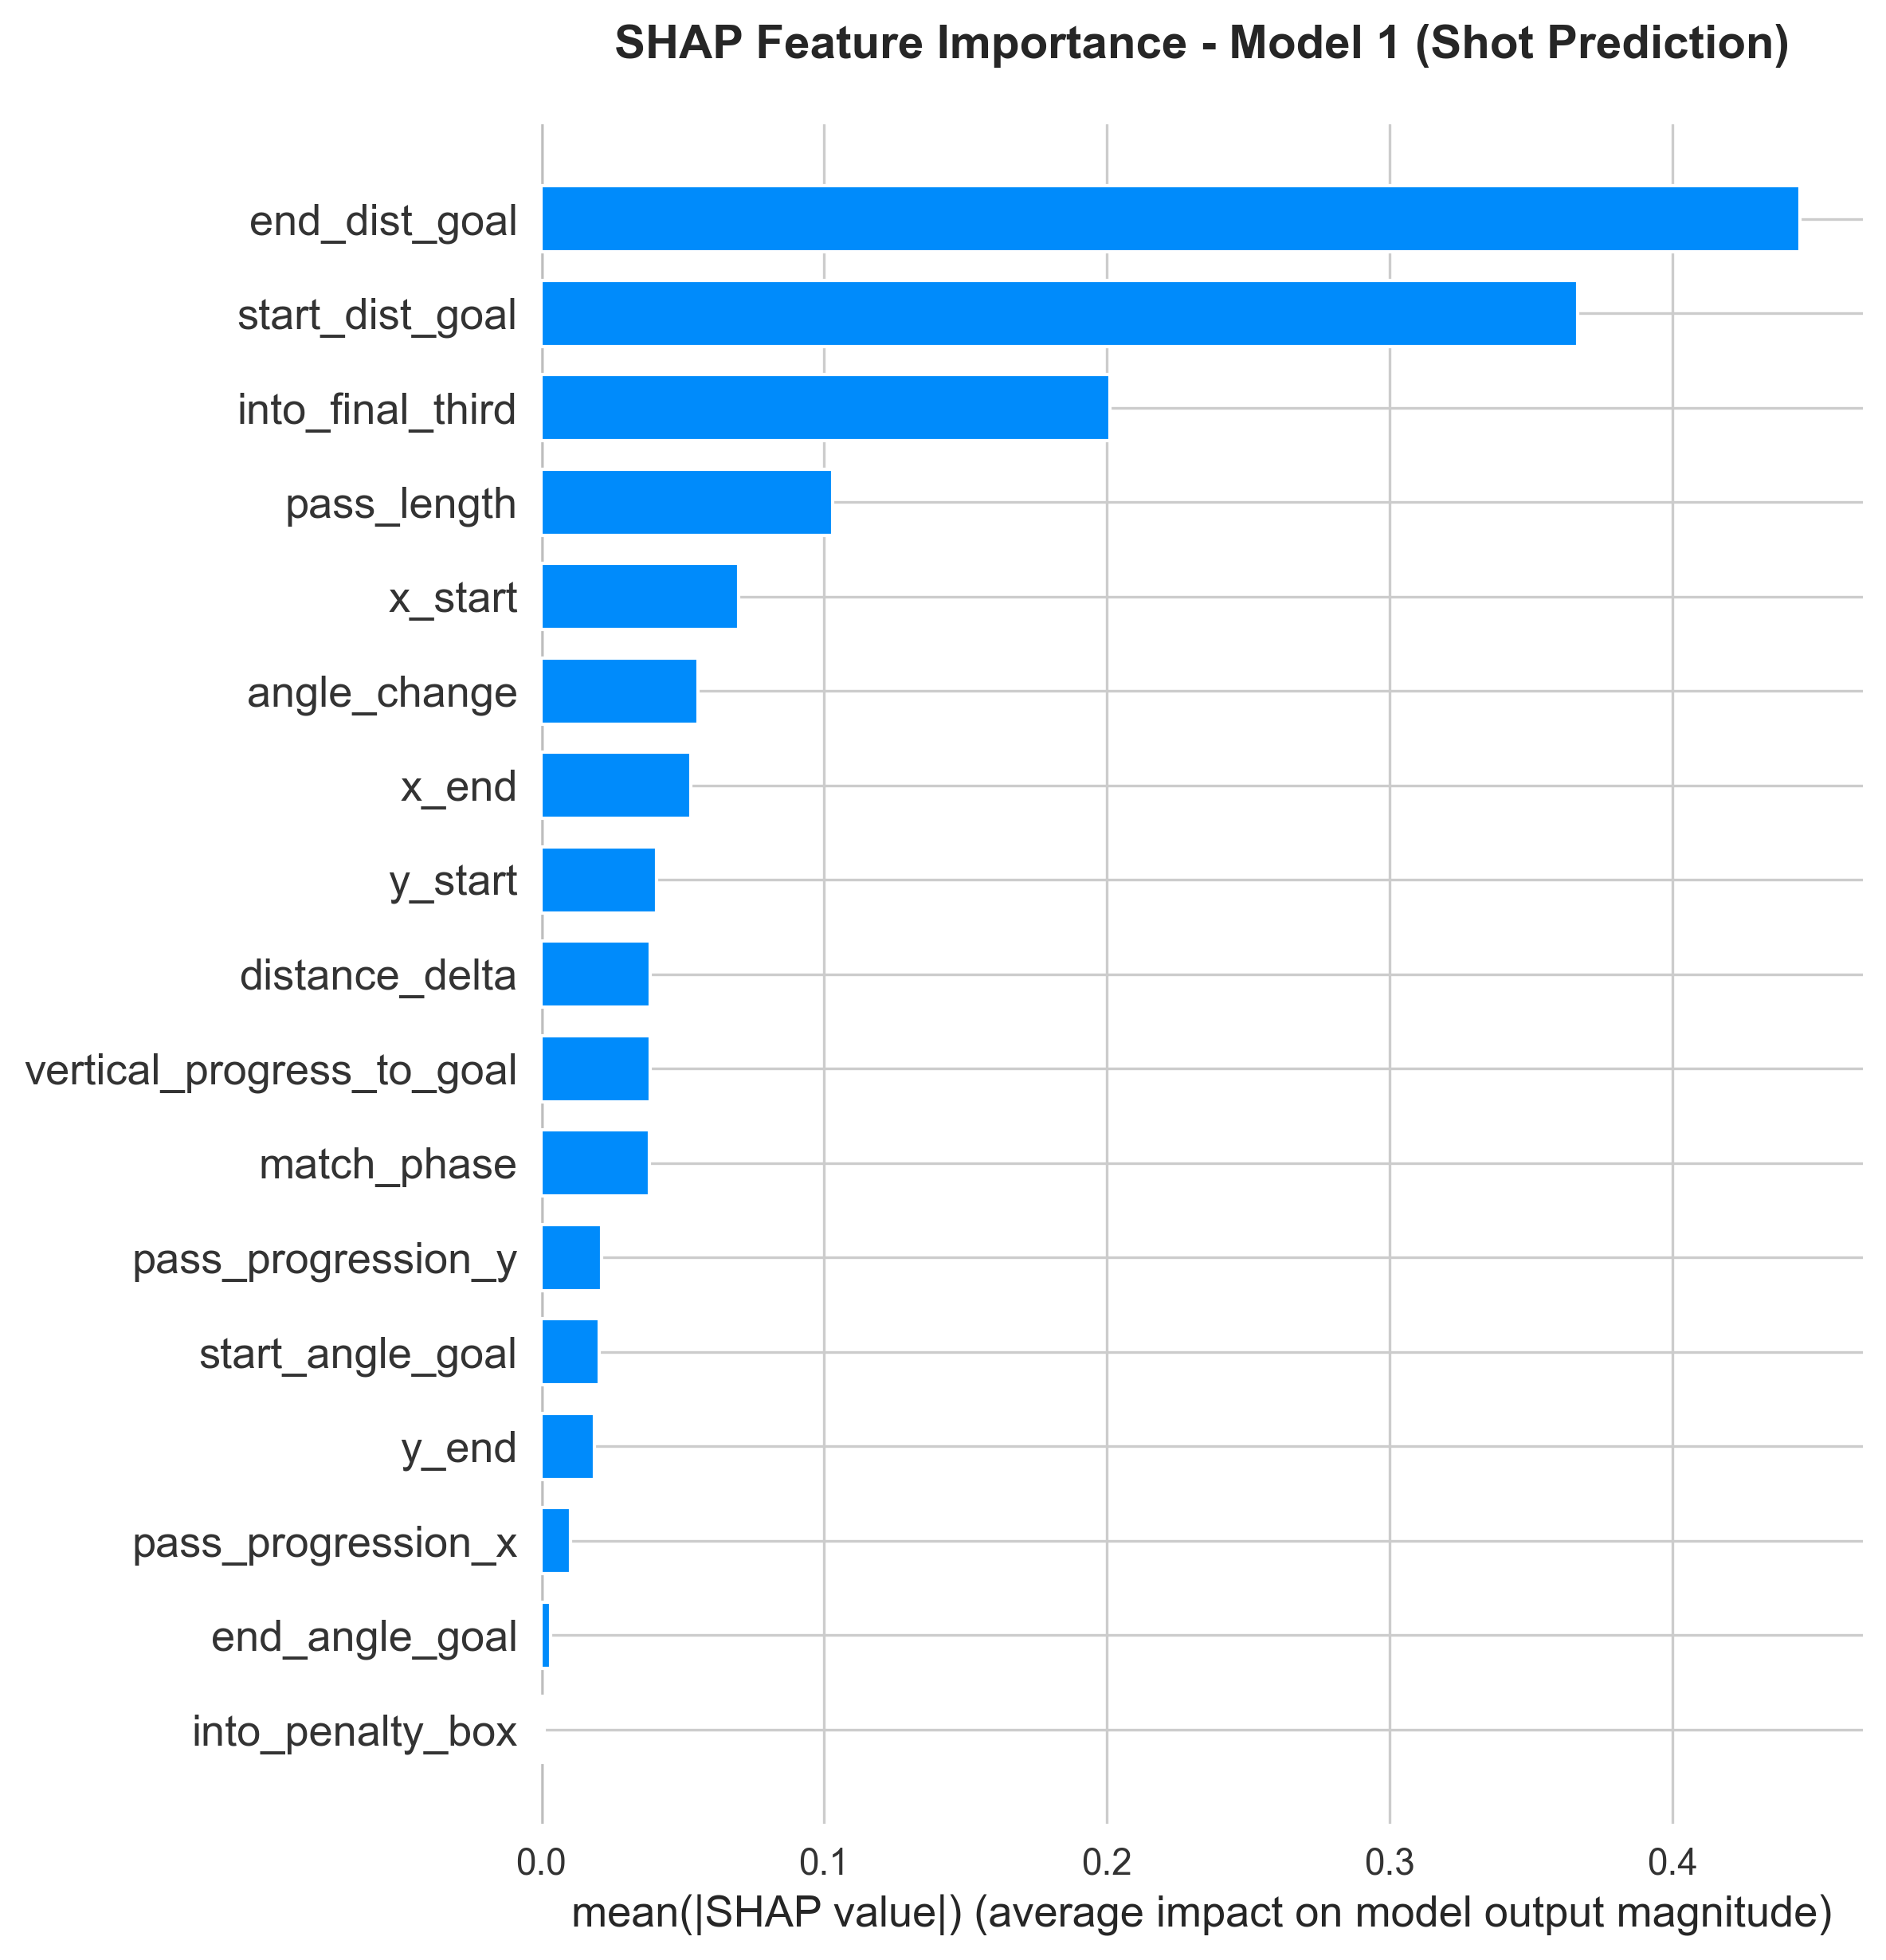

### Feature Effect Distribution

**V1 SHAP Beeswarm (shows feature values and their impact):**

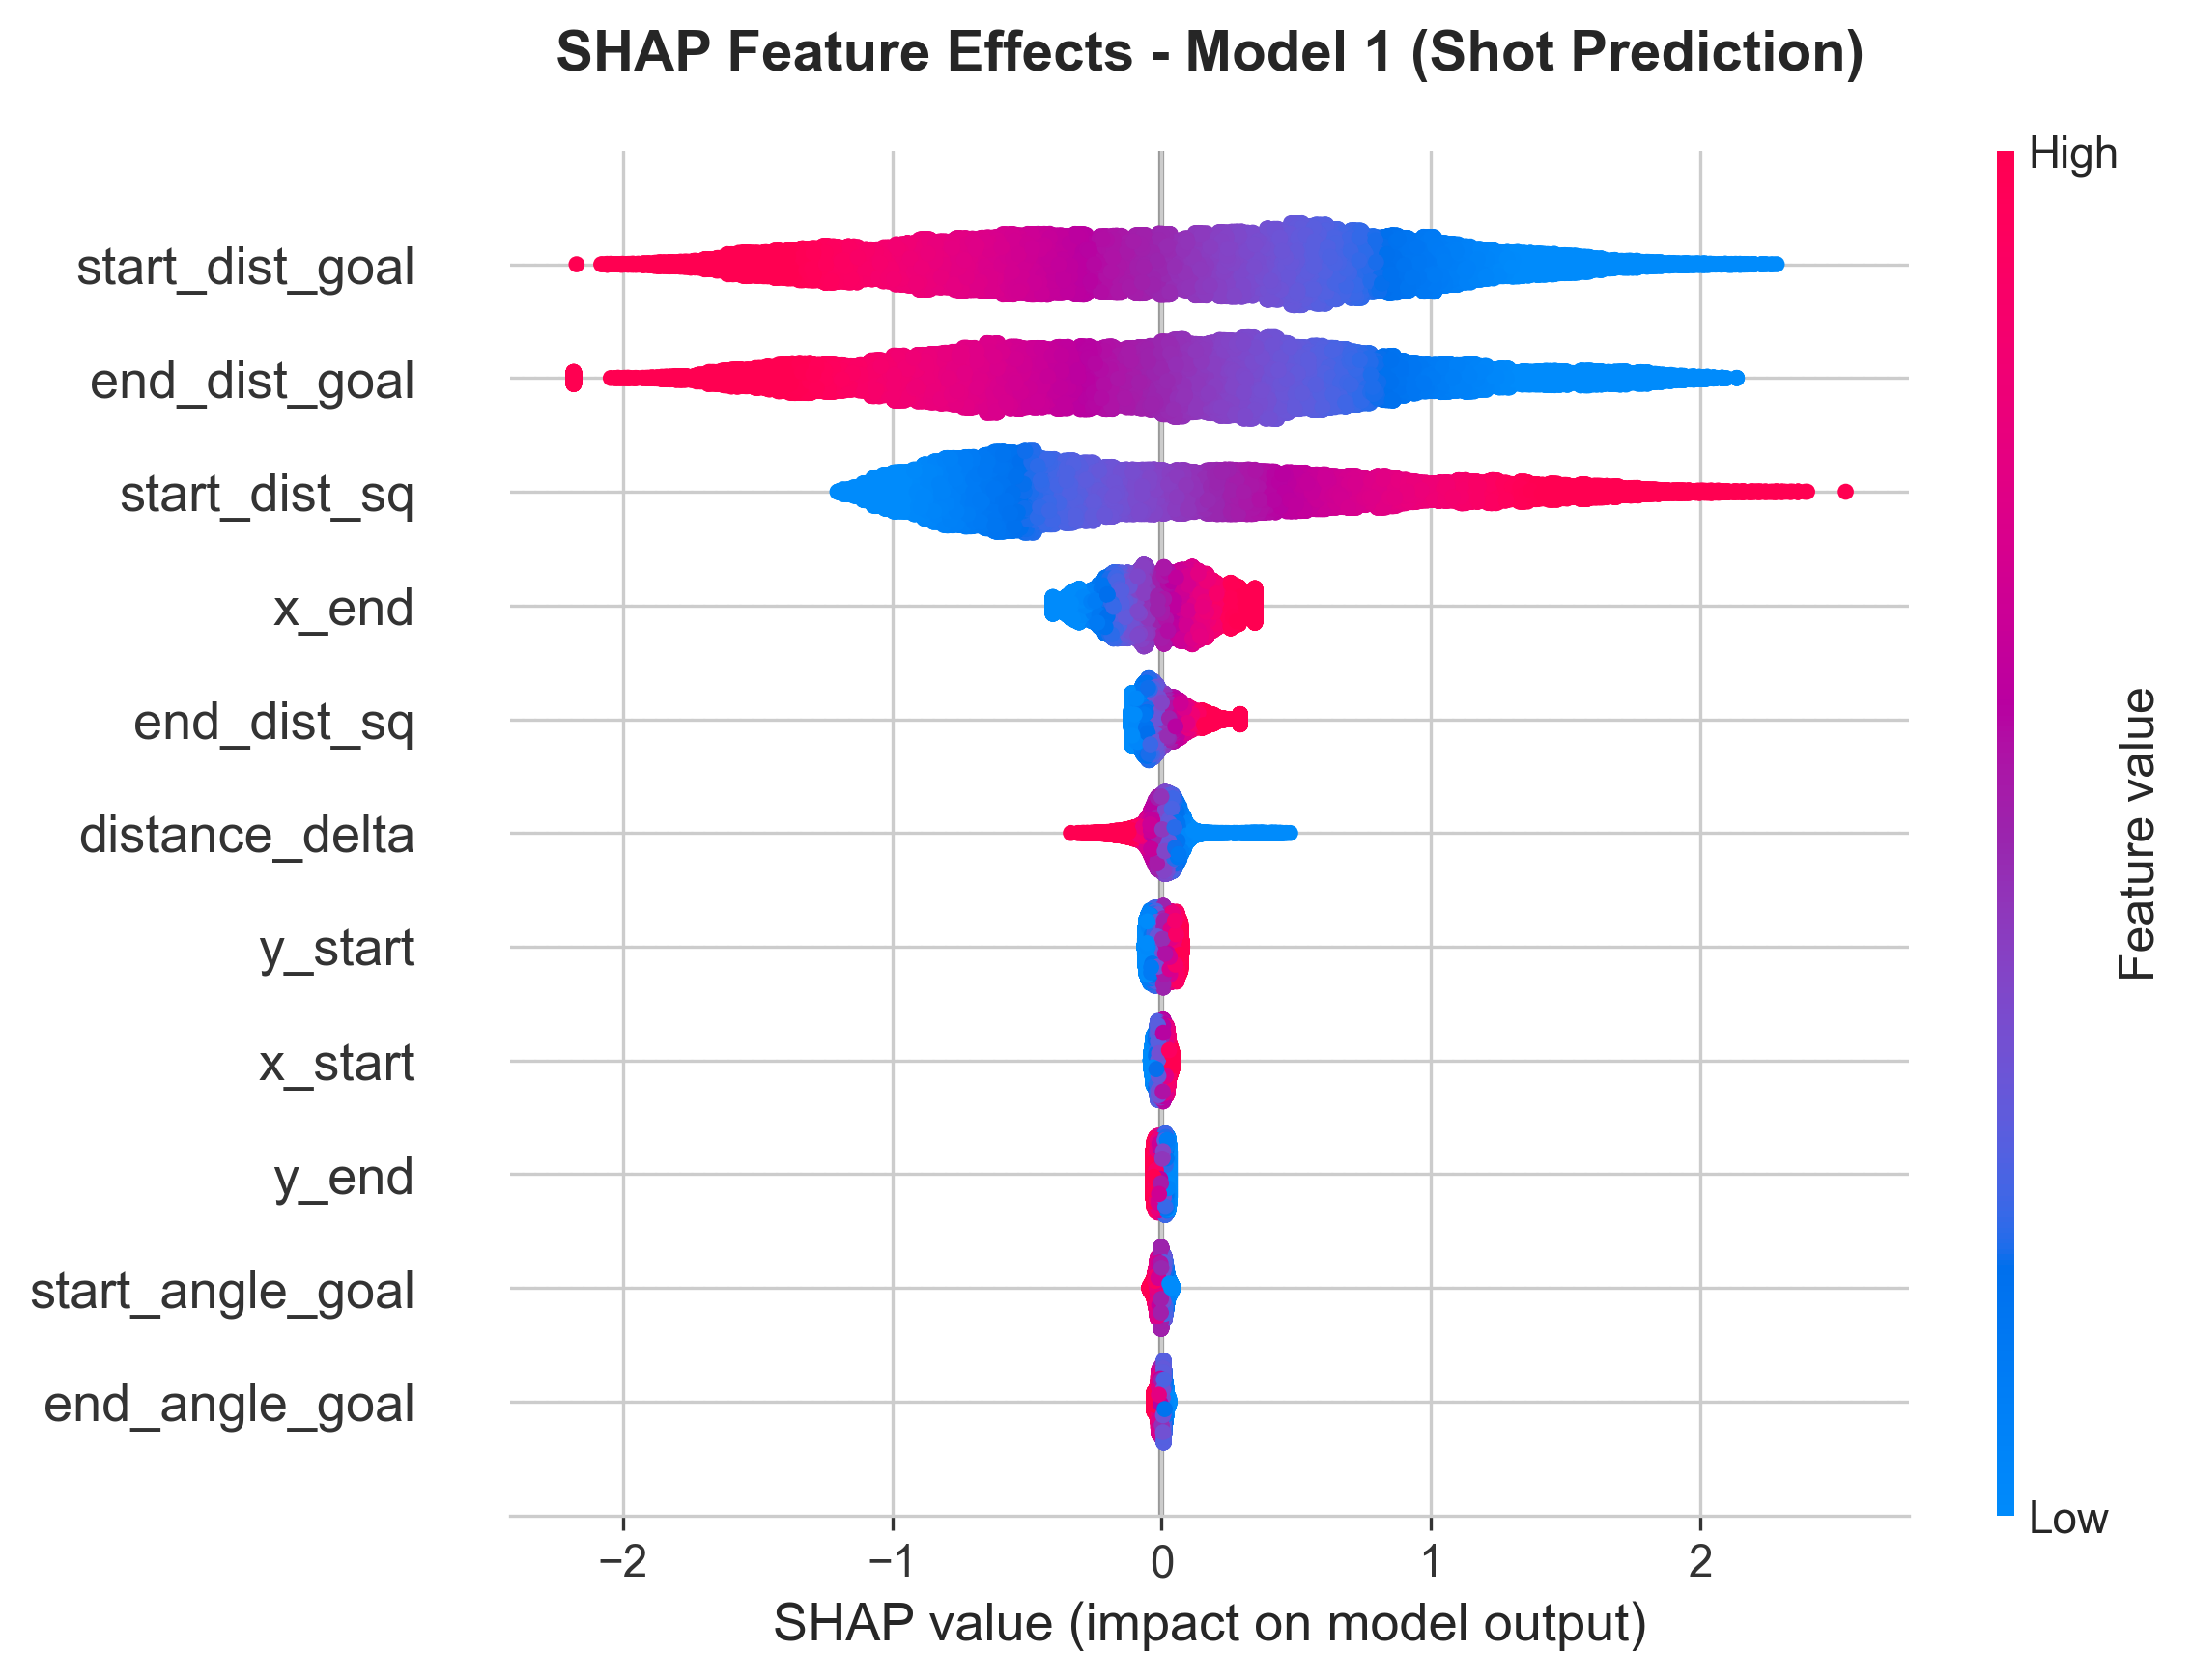

**V2 SHAP Beeswarm:**

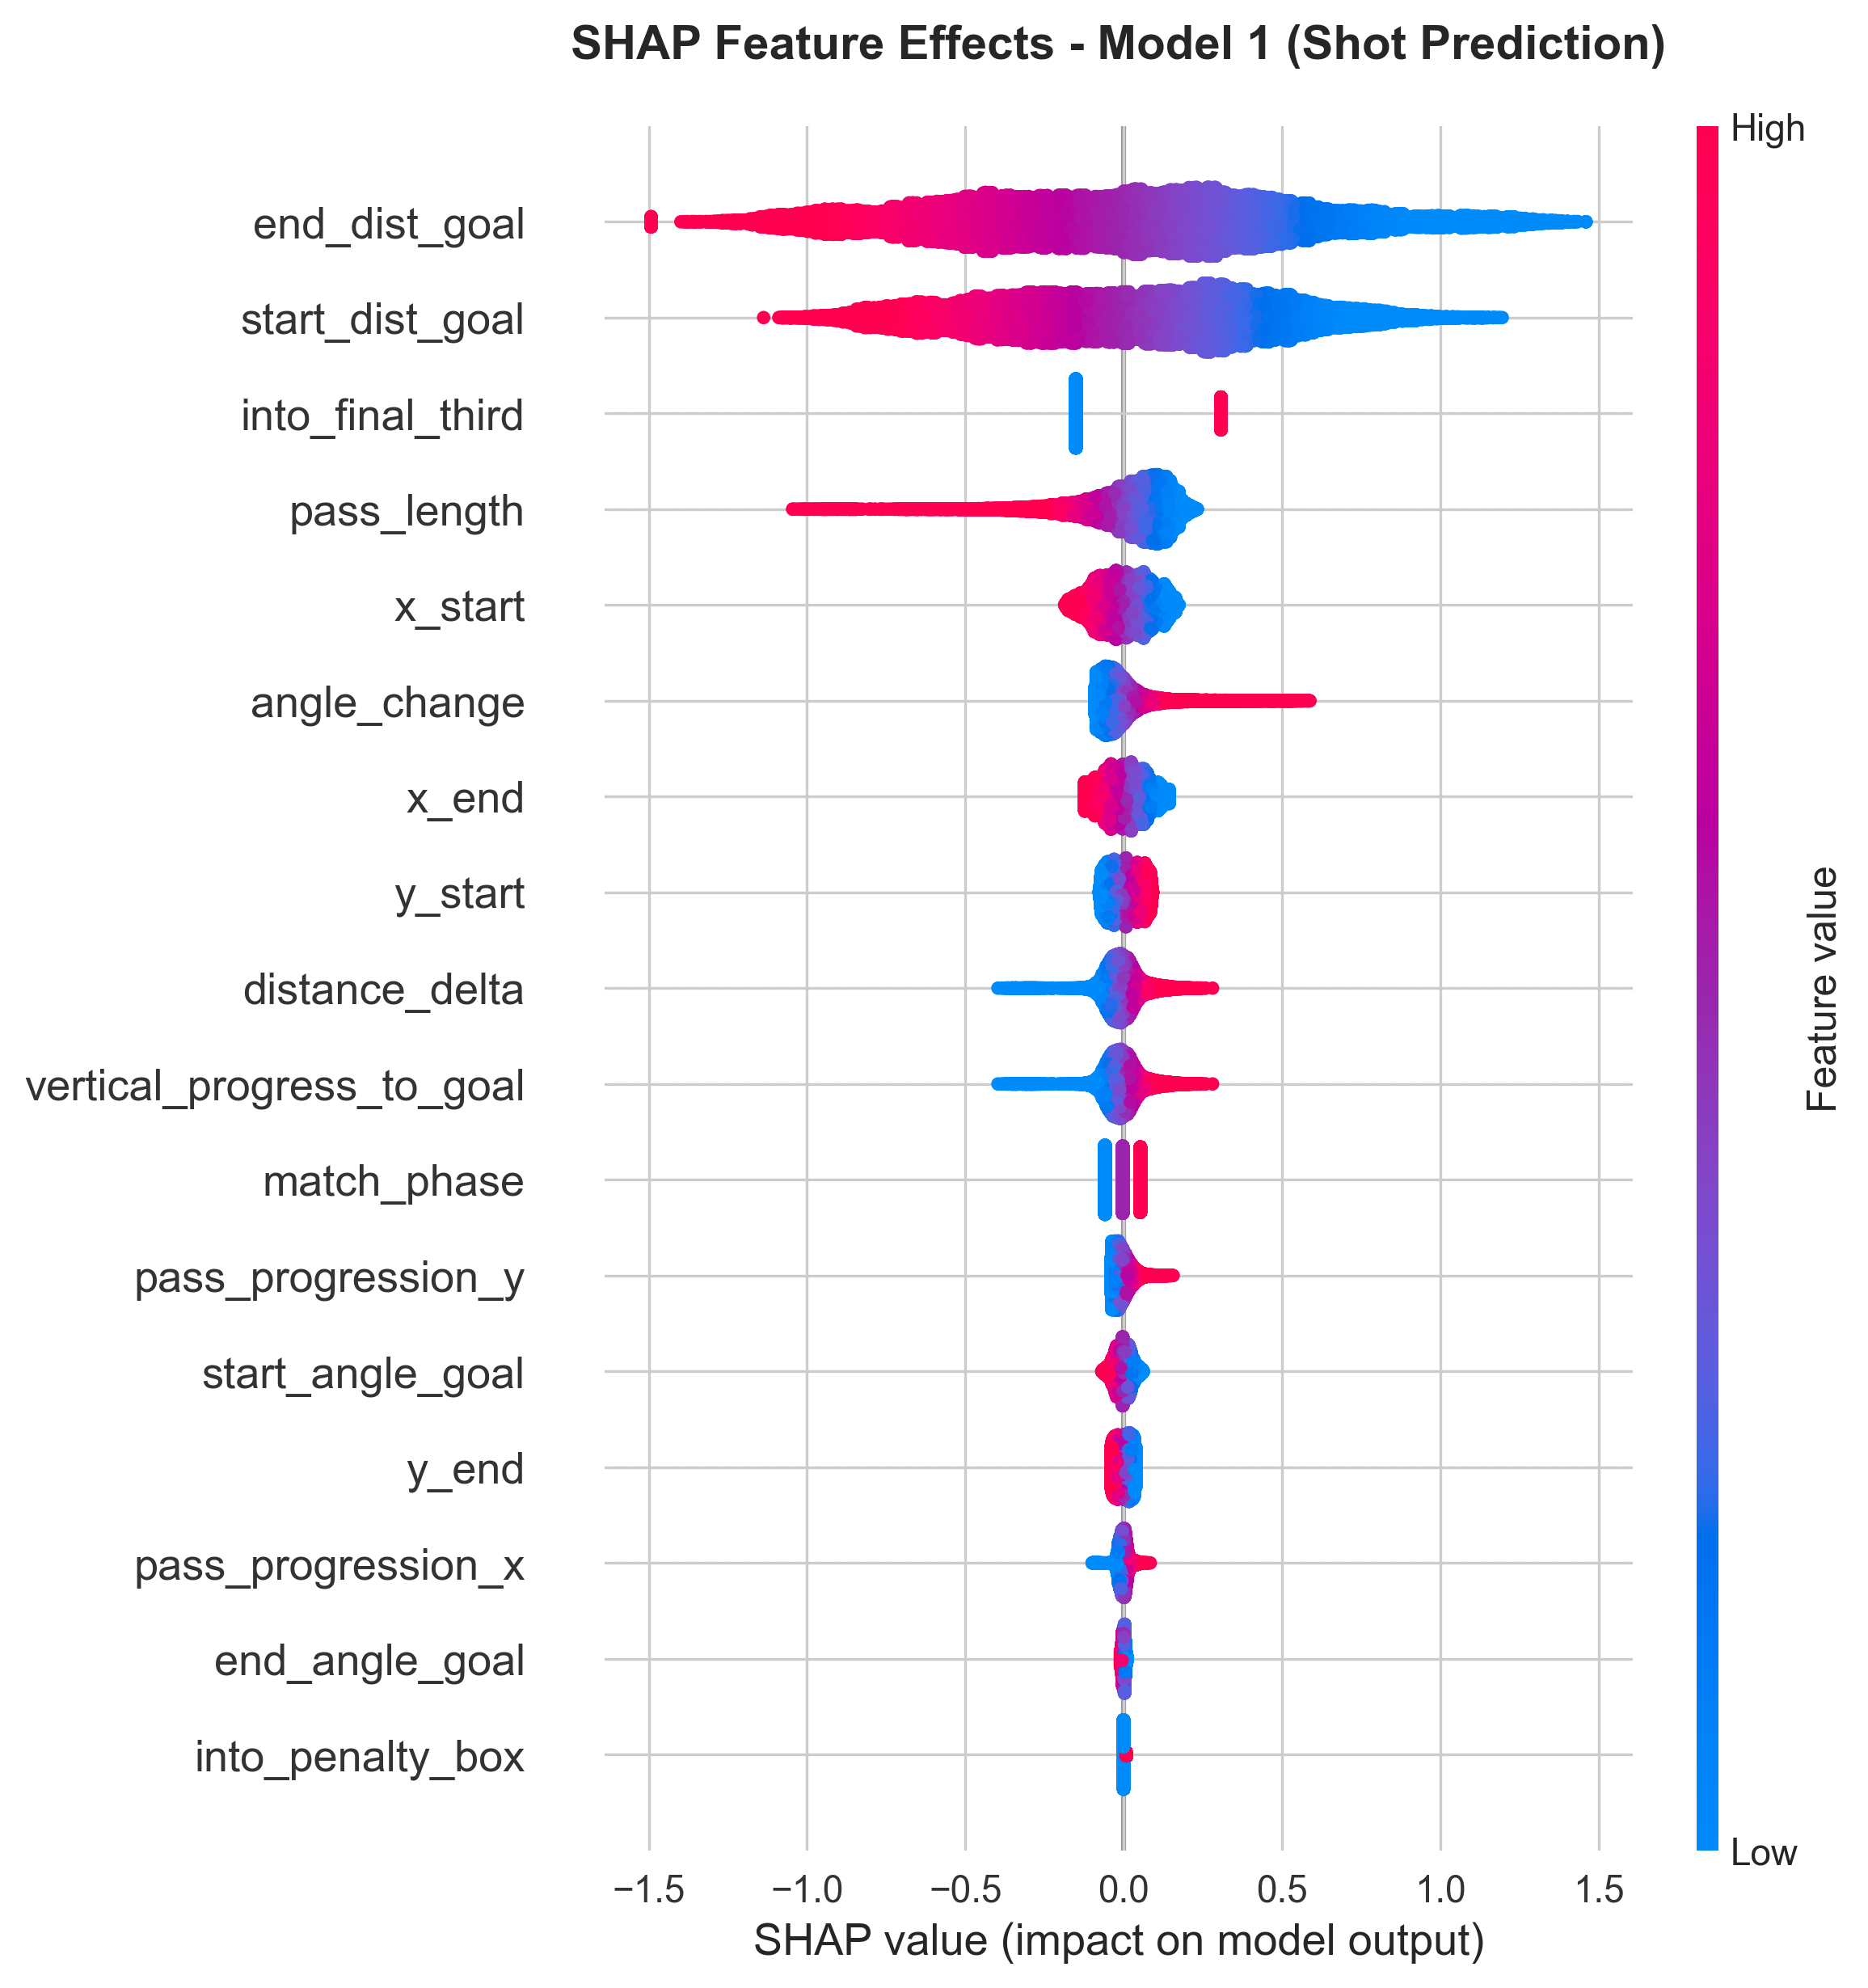

### 3. The Task Has Low Ceiling

Predicting shots from pass features is inherently difficult:
- **Only ~8% of passes** lead to shots
- Many contextual factors (defensive pressure, player skill, tactics) aren't captured
- Spatial features alone have limited predictive power

Both V1 and V2 have likely reached the **performance ceiling** for this feature set.

### 4. Consistency is Good

The similar performance actually **validates both models**:
- Player rankings remain stable (see comparison below)
- The core danger signal is robust
- Adding complexity didn't hurt performance (no overfitting)

### Player Rankings Comparison

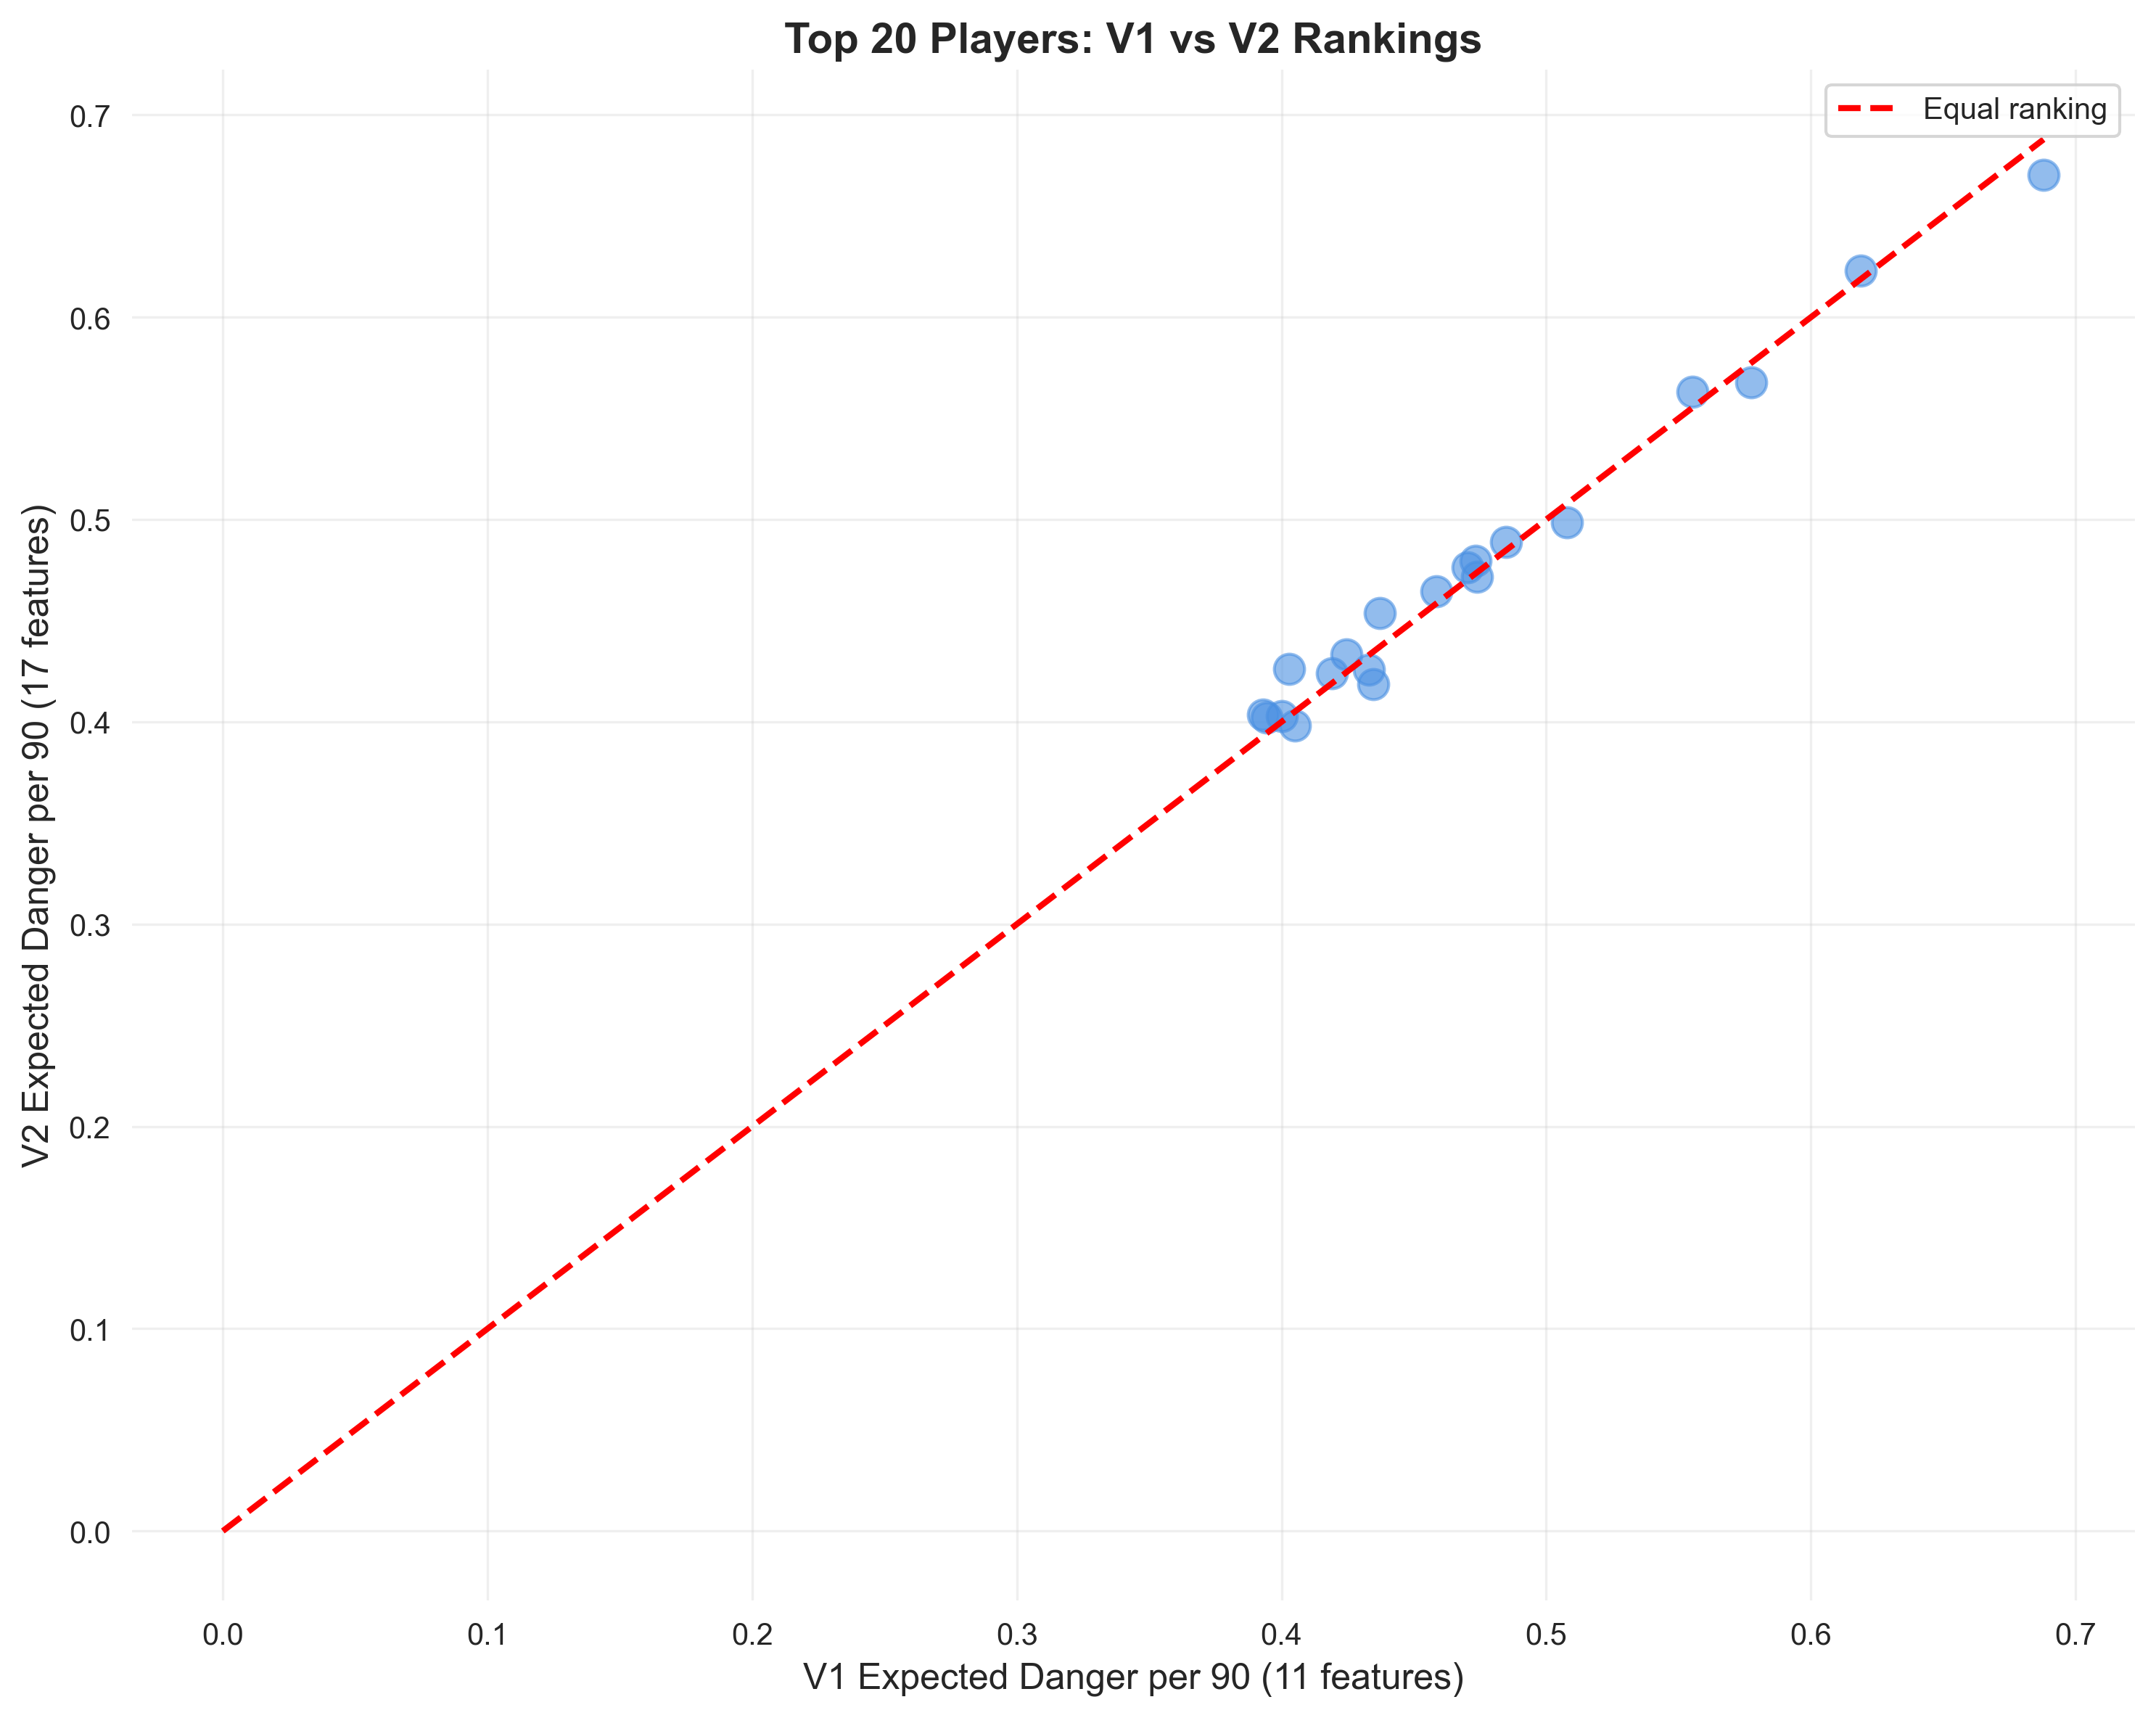

*Top 20 players remain largely consistent between V1 and V2, confirming model stability.*

### Conclusion

**V2 doesn't significantly outperform V1** because:
1. ✅ New features are correlated with existing ones (redundant information)
2. ✅ Distance-based features dominate the signal in both models
3. ✅ The task has a low performance ceiling given available features
4. ✅ Both models have reached similar optimal performance

**This is expected and acceptable** - it demonstrates that the original V1 features captured the essential danger signal effectively.


<div style="
    font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
    color: #033622;
    border-bottom: 3px solid #FF4B00;
    padding-bottom: 8px;
    margin: 32px 0 16px 0;
    font-size: 28px;
    font-weight: 700;
    letter-spacing: -0.5px;
    display: flex;
    align-items: center;
    gap: 12px;
">
    1. Data Loading
</div>

In [9]:
DATA_DIR = '../PL_2024_course/event_data'

def load_events(data_dir):
    all_events = []
    files = glob.glob(os.path.join(data_dir, '*.json'))
    print(f"Loading {len(files)} files from {data_dir}...")
    
    for i, f in enumerate(files):
        try:
            with open(f, 'r', encoding='utf-8') as file:
                data = json.load(file)
                if 'events' in data:
                    all_events.extend(data['events'])
        except Exception as e:
            print(f"Error reading {f}: {e}")
            
    print(f"Total events loaded: {len(all_events)}")
    return all_events

if os.path.exists(DATA_DIR):
    events = load_events(DATA_DIR)
else:
    print(f"Data directory not found: {DATA_DIR}")
    events = []

Loading 380 files from ../PL_2024_course/event_data...
Total events loaded: 630260


<div style="
    font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
    color: #033622;
    border-bottom: 3px solid #FF4B00;
    padding-bottom: 8px;
    margin: 32px 0 16px 0;
    font-size: 28px;
    font-weight: 700;
    letter-spacing: -0.5px;
    display: flex;
    align-items: center;
    gap: 12px;
">
    2. Preprocessing
</div>

In [10]:
def preprocess_data(events):
    if not events: return pd.DataFrame()
    df = pd.DataFrame(events)
    
    df['type_primary'] = df['type'].apply(lambda x: x.get('primary') if isinstance(x, dict) else None)
    
    keep_cols = ['matchId', 'id', 'team', 'player', 'type_primary', 'minute', 'second', 'location', 'pass', 'shot']
    keep_cols = [c for c in keep_cols if c in df.columns]
    df = df[keep_cols].copy()

    df['team_id'] = df['team'].apply(lambda x: x.get('id') if isinstance(x, dict) else None)

    df['time_seconds'] = df['minute'] * 60 + df['second']

    df.sort_values(by=['matchId', 'time_seconds'], inplace=True)
    
    return df

def identify_passes_and_shots(df):
    if df.empty: return pd.DataFrame(), pd.DataFrame()
    passes = df[df['type_primary'] == 'pass'].copy()
    shots = df[df['type_primary'] == 'shot'].copy()

    passes['x_start'] = passes['location'].apply(lambda x: x.get('x') if isinstance(x, dict) else np.nan)
    passes['y_start'] = passes['location'].apply(lambda x: x.get('y') if isinstance(x, dict) else np.nan)
    
    passes['x_end'] = passes['pass'].apply(lambda x: x.get('endLocation', {}).get('x') if isinstance(x, dict) else np.nan)
    passes['y_end'] = passes['pass'].apply(lambda x: x.get('endLocation', {}).get('y') if isinstance(x, dict) else np.nan)
    
    shots['is_goal'] = shots['shot'].apply(lambda x: x.get('isGoal') if isinstance(x, dict) else False)
    
    return passes, shots

df_all = preprocess_data(events)
passes, shots = identify_passes_and_shots(df_all)
print(f"Passes: {len(passes)}")
print(f"Shots: {len(shots)}")

Passes: 320903
Shots: 8750


<div style="
    font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
    color: #033622;
    border-bottom: 3px solid #FF4B00;
    padding-bottom: 8px;
    margin: 32px 0 16px 0;
    font-size: 28px;
    font-weight: 700;
    letter-spacing: -0.5px;
    display: flex;
    align-items: center;
    gap: 12px;
">
    3. Link Passes to Shots
</div>

In [11]:
def link_passes_to_shots(passes, shots, window_seconds=15):
    if len(shots) == 0:
        return passes
    
    match_ids = passes['matchId'].unique()
    print(f"Linking passes to shots for {len(match_ids)} matches...")
    
    linked_passes_list = []
    
    for mid in match_ids:
        m_passes = passes[passes['matchId'] == mid].copy()
        m_shots = shots[shots['matchId'] == mid]
        
        if m_shots.empty:
            m_passes['has_shot'] = 0
            m_passes['shot_is_goal'] = 0
            linked_passes_list.append(m_passes)
            continue
            
        m_passes = m_passes.sort_values('time_seconds')
        m_shots = m_shots.sort_values('time_seconds')
        
        p_records = m_passes.to_dict('records')
        s_records = m_shots.to_dict('records')
        
        shots_by_team = {}
        for s in s_records:
            tid = s['team_id']
            if tid not in shots_by_team:
                shots_by_team[tid] = []
            shots_by_team[tid].append(s)
            
        import bisect
        
        for p in p_records:
            t_start = p['time_seconds']
            t_end = t_start + window_seconds
            tid = p['team_id']
            
            p['has_shot'] = 0
            p['shot_is_goal'] = 0
            
            if tid in shots_by_team:
                team_shots = shots_by_team[tid]
                keys = [x['time_seconds'] for x in team_shots]
                start_idx = bisect.bisect_right(keys, t_start)
                
                for i in range(start_idx, len(team_shots)):
                    s = team_shots[i]
                    if s['time_seconds'] > t_end:
                        break
                    
                    p['has_shot'] = 1
                    if s['is_goal']:
                        p['shot_is_goal'] = 1
                    break
                    
        linked_passes_list.append(pd.DataFrame(p_records))
        
    return pd.concat(linked_passes_list, ignore_index=True)

linked_df = link_passes_to_shots(passes, shots)
print(f"Passes linked to shots: {linked_df['has_shot'].sum() if not linked_df.empty else 0}")

Linking passes to shots for 380 matches...
Passes linked to shots: 23477


<div style="
    font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
    color: #033622;
    border-bottom: 3px solid #FF4B00;
    padding-bottom: 8px;
    margin: 32px 0 16px 0;
    font-size: 28px;
    font-weight: 700;
    letter-spacing: -0.5px;
    display: flex;
    align-items: center;
    gap: 12px;
">
    4. Feature Engineering
</div>

In [12]:
def feature_engineering(df):
    if df.empty: return df
    print("Feature Engineering...")
    goal_x, goal_y = 100, 50
    
    df['start_dist_x'] = goal_x - df['x_start']
    df['start_dist_y'] = df['y_start'] - goal_y
    df['start_dist_goal'] = np.sqrt(df['start_dist_x']**2 + df['start_dist_y']**2)
    df['start_angle_goal'] = np.arctan2(df['start_dist_y'], df['start_dist_x'])
    
    df['end_dist_x'] = goal_x - df['x_end']
    df['end_dist_y'] = df['y_end'] - goal_y
    df['end_dist_goal'] = np.sqrt(df['end_dist_x']**2 + df['end_dist_y']**2)
    df['end_angle_goal'] = np.arctan2(df['end_dist_y'], df['end_dist_x'])
    
    df['start_dist_sq'] = df['start_dist_goal']**2
    df['end_dist_sq'] = df['end_dist_goal']**2
    
    df['distance_delta'] = df['start_dist_goal'] - df['end_dist_goal']
    
    return df

enriched_df = feature_engineering(linked_df)

Feature Engineering...


<div style="
    font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
    color: #033622;
    border-bottom: 3px solid #FF4B00;
    padding-bottom: 8px;
    margin: 32px 0 16px 0;
    font-size: 28px;
    font-weight: 700;
    letter-spacing: -0.5px;
    display: flex;
    align-items: center;
    gap: 12px;
">
    5. Model Training
</div>

In [13]:
def train_models(df):
    if df.empty: return None, None, []
    print("Training Models...")
    features = ['x_start', 'y_start', 'x_end', 'y_end', 
                'start_dist_goal', 'end_dist_goal', 
                'start_angle_goal', 'end_angle_goal',
                'start_dist_sq', 'end_dist_sq',
                'distance_delta']
                
    train_df = df.dropna(subset=features)
    X = train_df[features]
    
    y_shot = train_df['has_shot']
    
    print(f"Training Logistic Regression on {len(X)} samples (Target: has_shot)...")
    model1 = LogisticRegression(solver='lbfgs', max_iter=2000)
    model1.fit(X, y_shot)
    
    mask_shot = train_df['has_shot'] == 1
    X_shot = X[mask_shot]
    y_goal = train_df.loc[mask_shot, 'shot_is_goal']
    
    print(f"Training Linear Regression on {len(X_shot)} samples (Target: shot_is_goal)...")
    model2 = LinearRegression()
    model2.fit(X_shot, y_goal)
    
    return model1, model2, features

model1, model2, features = train_models(enriched_df)

Training Models...
Training Logistic Regression on 320903 samples (Target: has_shot)...
Training Linear Regression on 23477 samples (Target: shot_is_goal)...


<div style="
    font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
    color: #033622;
    border-bottom: 3px solid #FF4B00;
    padding-bottom: 8px;
    margin: 32px 0 16px 0;
    font-size: 28px;
    font-weight: 700;
    letter-spacing: -0.5px;
    display: flex;
    align-items: center;
    gap: 12px;
">
    6. Prediction and Ranking
</div>

In [14]:
def predict_ed(df, model1, model2, features):
    if df.empty or model1 is None: return df
    X = df[features].fillna(0)
    
    prob_shot = model1.predict_proba(X)[:, 1]
    prob_goal_given_shot = model2.predict(X)

    prob_goal_given_shot = np.clip(prob_goal_given_shot, 0, 1)
    
    df['prob_shot'] = prob_shot
    df['prob_goal'] = prob_goal_given_shot
    df['expected_danger'] = prob_shot * prob_goal_given_shot
    
    return df

MINUTES_PATH = '../PL_2024_course/minutes.parquet'

def analyze_rankings(df):
    if df.empty: return df
    print("Analyzing Rankings...")
    if not os.path.exists(MINUTES_PATH):
        print("Minutes file not found. Skipping per 90 stats.")
        return df
        
    min_df = pd.read_parquet(MINUTES_PATH)
    player_minutes = min_df.groupby('player_id')['minutes'].sum().reset_index()
    
    players_list = df['player'].tolist()
    p_ids = [p['id'] if p and isinstance(p, dict) else None for p in players_list]
    p_names = [p['name'] if p and isinstance(p, dict) else None for p in players_list]
    p_pos = [p['position'] if p and isinstance(p, dict) else None for p in players_list]
    
    df['player_id'] = p_ids
    df['player_name'] = p_names
    df['player_pos'] = p_pos

    teams_list = df['team'].tolist()
    t_names = [t.get('name') if t and isinstance(t, dict) else None for t in teams_list]
    df['team_name'] = t_names
    
    df_clean = df.dropna(subset=['player_id'])

    stats = df_clean.groupby(['player_id', 'player_name', 'player_pos']).agg({
        'expected_danger': 'sum',
        'has_shot': 'sum',
        'id': 'count',
        'team_name': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
    }).reset_index()
    
    stats.rename(columns={'has_shot': 'danger_passes', 'id': 'total_passes'}, inplace=True)
    
    stats = stats.merge(player_minutes, on='player_id', how='left')
    stats = stats[stats['minutes'] >= 900].copy()
    
    stats['ed_per_90'] = (stats['expected_danger'] / stats['minutes']) * 90
    stats['danger_passes_per_90'] = (stats['danger_passes'] / stats['minutes']) * 90
    
    stats.sort_values('ed_per_90', ascending=False, inplace=True)
    
    return stats

final_df = predict_ed(enriched_df, model1, model2, features)
stats = analyze_rankings(final_df)

if not stats.empty:
    print("Top 10 Players by Expected Danger per 90:")
    display(stats[['player_name', 'player_pos', 'ed_per_90', 'team_name']].head(10))

Analyzing Rankings...
Top 10 Players by Expected Danger per 90:


,player_name,player_pos,ed_per_90,team_name
826,T. Alexander-Arnold,RB,0.685771,Liverpool
740,M. Ødegaard,RCMF3,0.622739,Arsenal
290,K. De Bruyne,AMF,0.579931,Manchester City
96,K. Walker,RB,0.552157,Manchester City
1939,Pedro Porro,RB,0.504972,Tottenham Hotspur
140,K. Trippier,RB,0.481601,Newcastle United
1948,I. Maatsen,LB,0.475136,Aston Villa
421,A. Robertson,LB,0.475028,Liverpool
2071,M. Gusto,RB,0.469401,Chelsea
2342,A. Wharton,RCMF,0.458007,Crystal Palace


<div style="
    font-family: -apple-system,BlinkMacSystemFont,'Segoe UI',Roboto,sans-serif;
    color: #033622;
    border-bottom: 3px solid #FF4B00;
    padding-bottom: 8px;
    margin: 32px 0 16px 0;
    font-size: 28px;
    font-weight: 700;
    letter-spacing: -0.5px;
    display: flex;
    align-items: center;
    gap: 12px;
">
    7. Visualizations
</div>

### 3D Expected Danger



### Top Danger Creators



### Position-Based Rankings

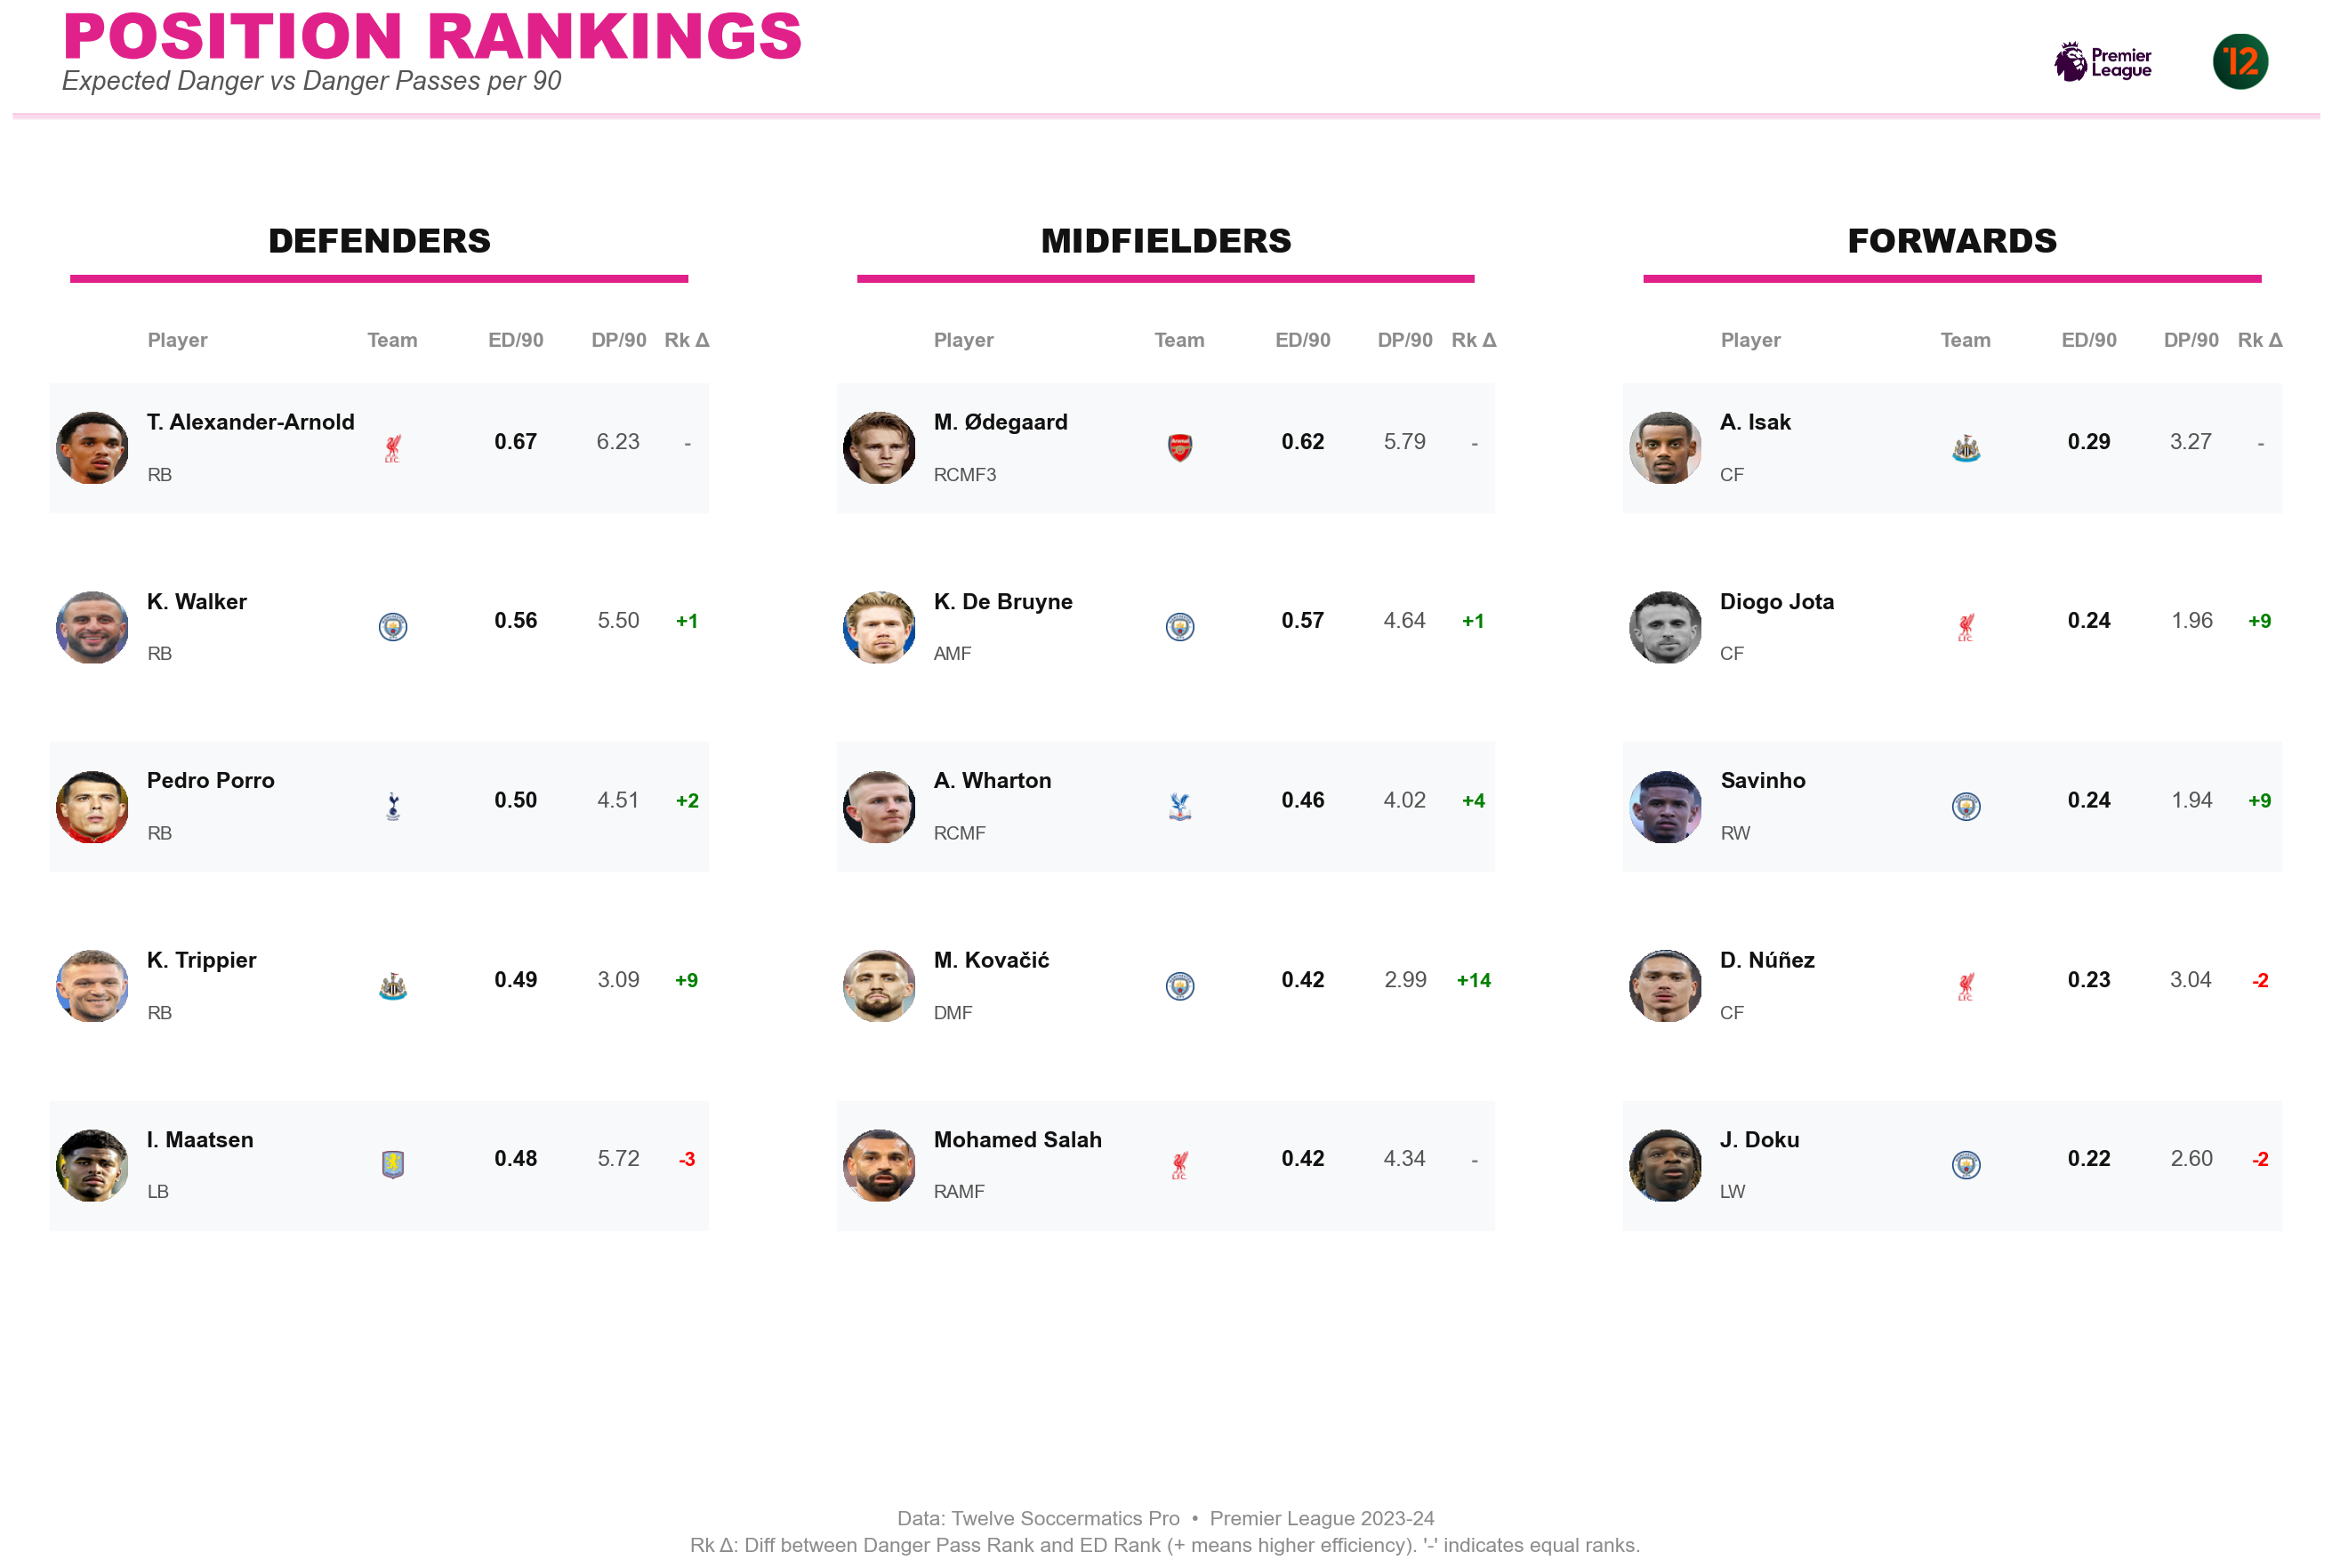